In [4]:
import pandas as pd

In [10]:
data = pd.read_csv("/Users/prathikraju/Documents/Scaler case study/Netflix_case_study/netflix.csv")

In [12]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [14]:
data.shape
print("Shape:", data.shape)

Shape: (8807, 12)


In [16]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [26]:
data.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [42]:
data['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [48]:
data['rating'].value_counts(dropna = False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [66]:
bad_rows = data['rating'].isin(['74 min','84 min','66 min'])
data[bad_rows][['title', 'type', 'rating', 'duration']]

,title,type,rating,duration
5541,Louis C.K. 2017,Movie,74 min,NaN
5794,Louis C.K.: Hilarious,Movie,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,Movie,66 min,NaN


In [70]:
data.loc[bad_rows, 'duration'] = data.loc[bad_rows, 'rating']

In [72]:
data.loc[bad_rows, 'rating'] = None

In [74]:
data[bad_rows][['title', 'type', 'rating', 'duration']]

,title,type,rating,duration
5541,Louis C.K. 2017,Movie,None,74 min
5794,Louis C.K.: Hilarious,Movie,None,84 min
5813,Louis C.K.: Live at the Comedy Store,Movie,None,66 min


In [78]:
data['rating'].isnull().sum()

7

In [82]:
data['type'] = data['type'].astype('category')

In [86]:
data['type'].dtype

CategoricalDtype(categories=['Movie', 'TV Show'], ordered=False, categories_dtype=object)

In [90]:
data['date_added'] = data['date_added'].str.strip()

In [94]:
data['date_added'] = pd.to_datetime(data['date_added'], errors = 'coerce')

In [98]:
data['date_added'].dtype

dtype('<M8[ns]')

In [100]:
data['date_added'].isna().sum()

10

In [102]:
data['date_added'].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [110]:
data['director'].isna().sum() / len(data['director']) * 100

29.908027705234474

In [108]:
data['director'].isna().sum()

2634

In [116]:
data['type'].value_counts() / len(data['type']) * 100

type
Movie      69.615079
TV Show    30.384921
Name: count, dtype: float64

In [120]:
data['year'] = data['date_added'].dt.year

In [128]:
data.groupby(['year','type']).size()

/var/folders/70/fpb7f1jd16lfs40_zf7jzz7r0000gn/T/ipykernel_79690/683730573.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['year','type']).size()


year    type   
2008.0  Movie         1
        TV Show       1
2009.0  Movie         2
        TV Show       0
2010.0  Movie         1
        TV Show       0
2011.0  Movie        13
        TV Show       0
2012.0  Movie         3
        TV Show       0
2013.0  Movie         6
        TV Show       5
2014.0  Movie        19
        TV Show       5
2015.0  Movie        56
        TV Show      26
2016.0  Movie       253
        TV Show     176
2017.0  Movie       839
        TV Show     349
2018.0  Movie      1237
        TV Show     412
2019.0  Movie      1424
        TV Show     592
2020.0  Movie      1284
        TV Show     595
2021.0  Movie       993
        TV Show     505
dtype: int64

In [338]:
year_type_pct = round(pd.crosstab(data['year'], data['type'], normalize = 'index') *100 ,2)
year_type_pct

type,Movie,TV Show
year,,
2008.0,50.00,50.00
2009.0,100.00,0.00
2010.0,100.00,0.00
2011.0,100.00,0.00
2012.0,100.00,0.00
2013.0,54.55,45.45
2014.0,79.17,20.83
2015.0,68.29,31.71
2016.0,58.97,41.03


In [136]:
data.groupby('year').size()

year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
dtype: int64

In [150]:
genre_split = data['listed_in'].dropna().str.split(',')

In [152]:
all_genre = genre_split.explode().str.strip()

In [154]:
all_genre.unique()

array(['Documentaries', 'International TV Shows', 'TV Dramas',
       'TV Mysteries', 'Crime TV Shows', 'TV Action & Adventure',
       'Docuseries', 'Reality TV', 'Romantic TV Shows', 'TV Comedies',
       'TV Horror', 'Children & Family Movies', 'Dramas',
       'Independent Movies', 'International Movies', 'British TV Shows',
       'Comedies', 'Spanish-Language TV Shows', 'Thrillers',
       'Romantic Movies', 'Music & Musicals', 'Horror Movies',
       'Sci-Fi & Fantasy', 'TV Thrillers', "Kids' TV",
       'Action & Adventure', 'TV Sci-Fi & Fantasy', 'Classic Movies',
       'Anime Features', 'Sports Movies', 'Anime Series',
       'Korean TV Shows', 'Science & Nature TV', 'Teen TV Shows',
       'Cult Movies', 'TV Shows', 'Faith & Spirituality', 'LGBTQ Movies',
       'Stand-Up Comedy', 'Movies', 'Stand-Up Comedy & Talk Shows',
       'Classic & Cult TV'], dtype=object)

In [156]:
len(all_genre.unique())

42

In [158]:
all_genre.value_counts()

listed_in
International Movies            2752
Dramas                          2427
Comedies                        1674
International TV Shows          1351
Documentaries                    869
Action & Adventure               859
TV Dramas                        763
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
TV Comedies                      581
Thrillers                        577
Crime TV Shows                   470
Kids' TV                         451
Docuseries                       395
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     176
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Shows             

In [184]:
countries_split = data['country'].dropna().str.split(',')

In [188]:
all_countries = countries_split.explode().str.strip()

In [190]:
all_countries.unique()

array(['United States', 'South Africa', 'India', 'Ghana', 'Burkina Faso',
       'United Kingdom', 'Germany', 'Ethiopia', 'Czech Republic',
       'Mexico', 'Turkey', 'Australia', 'France', 'Finland', 'China',
       'Canada', 'Japan', 'Nigeria', 'Spain', 'Belgium', 'South Korea',
       'Singapore', 'Italy', 'Romania', 'Argentina', 'Venezuela',
       'Hong Kong', 'Russia', '', 'Ireland', 'Nepal', 'New Zealand',
       'Brazil', 'Greece', 'Jordan', 'Colombia', 'Switzerland', 'Israel',
       'Taiwan', 'Bulgaria', 'Algeria', 'Poland', 'Saudi Arabia',
       'Thailand', 'Indonesia', 'Egypt', 'Denmark', 'Kuwait',
       'Netherlands', 'Malaysia', 'Vietnam', 'Hungary', 'Sweden',
       'Lebanon', 'Syria', 'Philippines', 'Iceland',
       'United Arab Emirates', 'Norway', 'Qatar', 'Mauritius', 'Austria',
       'Cameroon', 'Palestine', 'Uruguay', 'Kenya', 'Chile', 'Luxembourg',
       'Cambodia', 'Bangladesh', 'Portugal', 'Cayman Islands', 'Senegal',
       'Serbia', 'Malta', 'Namibia', 'A

In [192]:
len(all_countries.unique())

123

In [194]:
all_countries.value_counts().head(15)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Name: count, dtype: int64

In [204]:
round(data['rating'].value_counts()/ len(data['rating'].dropna()) * 100, 2)

rating
TV-MA       36.44
TV-14       24.55
TV-PG        9.81
R            9.08
PG-13        5.57
TV-Y7        3.80
TV-Y         3.49
PG           3.26
TV-G         2.50
NR           0.91
G            0.47
TV-Y7-FV     0.07
NC-17        0.03
UR           0.03
Name: count, dtype: float64

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

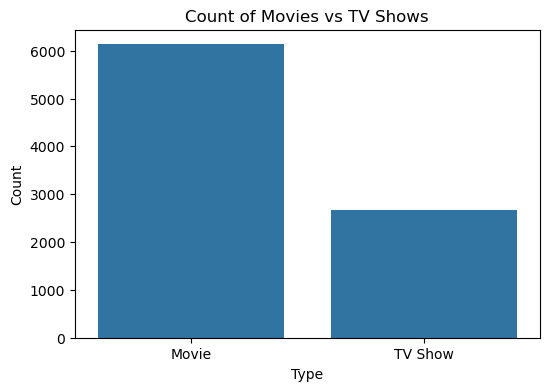

In [220]:
plt.figure(figsize = (6,4))
sns.countplot(data = data, x = 'type')
plt.title('Count of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

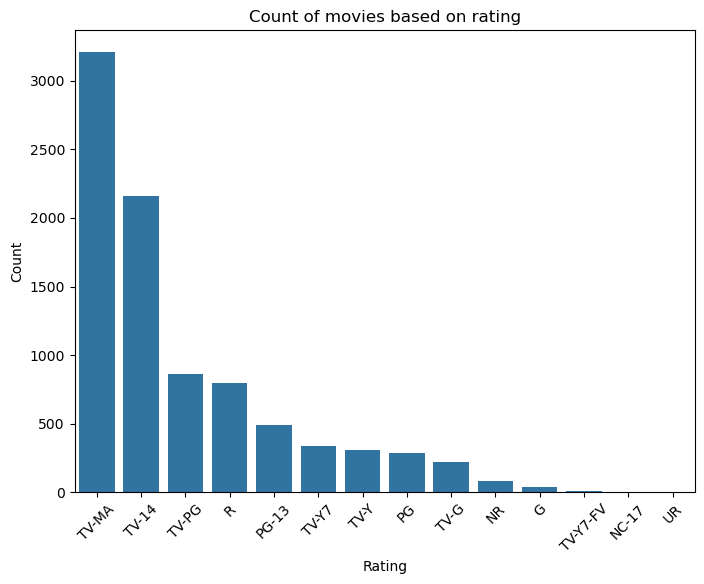

In [252]:
rating_order = data['rating'].value_counts().index

plt.figure(figsize = (8,6))
sns.countplot(data = data, x='rating', order = rating_order)
plt.title('Count of movies based on rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

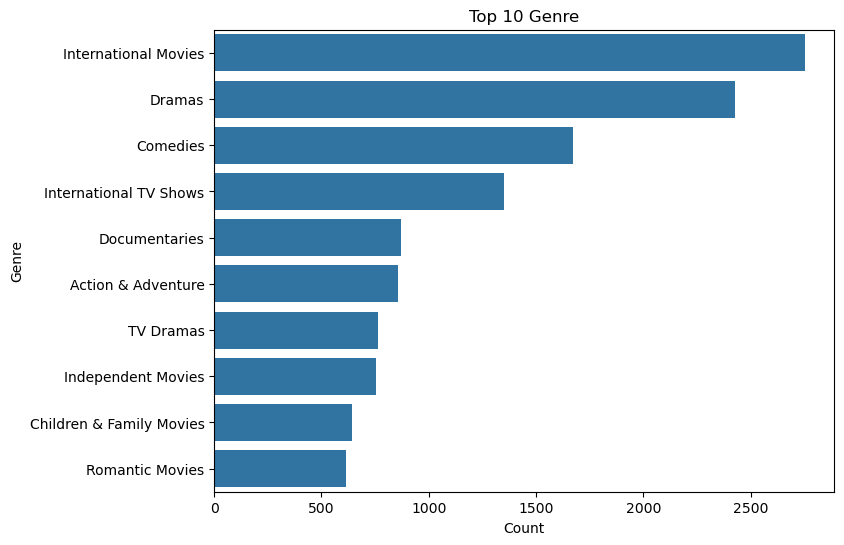

In [248]:
genre_counts = all_genre.value_counts().head(10)

plt.figure(figsize = (8,6))
sns.barplot(x= genre_counts.values, y= genre_counts.index)
plt.title('Top 10 Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

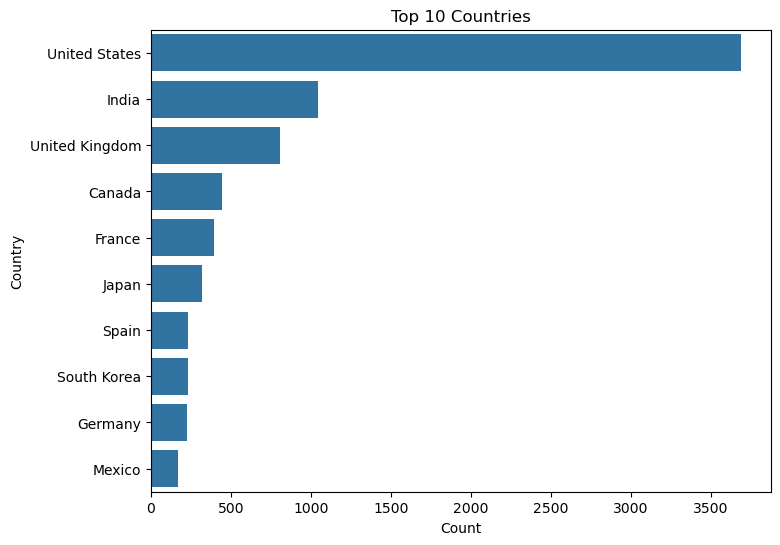

In [260]:
country_order = all_countries.value_counts().head(10)

plt.figure(figsize =(8,6))
sns.barplot(x = country_order.values, y = country_order.index)
plt.title('Top 10 Countries')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

In [274]:
country_type = data[['country', 'type']].dropna()

In [276]:
country_type['country'] = country_type['country'].str.split(', ')

In [278]:
country_type = country_type.explode('country')

In [280]:
country_type['country'] = country_type['country'].str.strip()

In [282]:
country_type.head()

,country,type
0,United States,Movie
1,South Africa,TV Show
4,India,TV Show
7,United States,Movie
7,Ghana,Movie


In [284]:
top10 = ['United States', 'India', 'United Kingdom', 'Canada', 'France', 
         'Japan', 'Spain', 'South Korea', 'Germany', 'Mexico']

In [310]:
filtered = country_type[country_type['country'].isin(top10)]
country_type_percentage = round(pd.crosstab(filtered['country'], filtered['type'], normalize='index') * 100, 2)
country_type_percentage

type,Movie,TV Show
country,,
Canada,71.69,28.31
France,77.10,22.90
Germany,80.53,19.47
India,91.97,8.03
Japan,37.42,62.58
Mexico,65.68,34.32
South Korea,26.41,73.59
Spain,73.71,26.29
United Kingdom,66.17,33.83


In [328]:
country_type_percentage = country_type_percentage.sort_values('Movie', ascending = True)

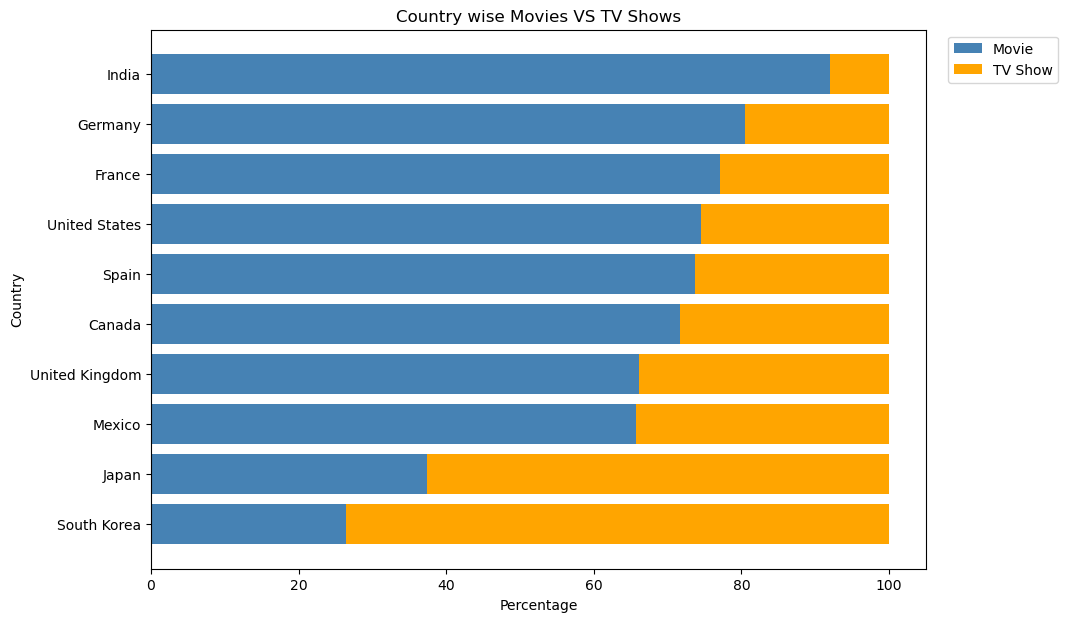

In [332]:
plt.figure(figsize = (10,7))
plt.barh(country_type_percentage.index, country_type_percentage['Movie'], label = 'Movie', color = 'steelblue')
plt.barh(country_type_percentage.index, country_type_percentage['TV Show'], left = country_type_percentage['Movie'], label = 'TV Show', color = 'orange')
plt.title("Country wise Movies VS TV Shows")
plt.xlabel('Percentage')
plt.ylabel('Country')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

In [350]:
year_type_pct_filtered = year_type_pct[year_type_pct.index >= 2015]

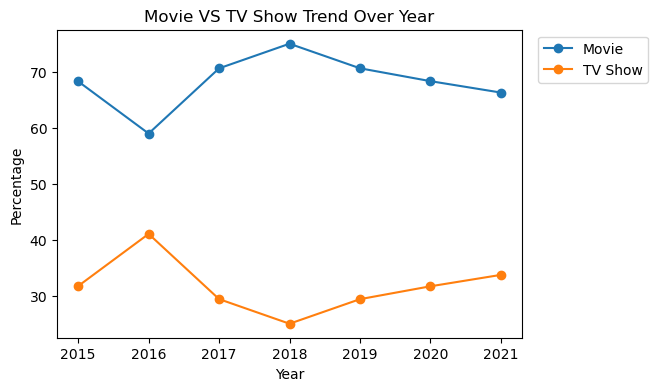

In [354]:
plt.figure(figsize = (6,4))
plt.plot(year_type_pct_filtered.index, year_type_pct_filtered['Movie'], marker = 'o', label = 'Movie')
plt.plot(year_type_pct_filtered.index, year_type_pct_filtered['TV Show'], marker = 'o', label = 'TV Show')
plt.title('Movie VS TV Show Trend Over Year')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

In [358]:
data['duration_num'] = data['duration'].str.split(' ').str[0].astype(int)

In [362]:
data['duration_num'].isnull().sum()

0

In [364]:
data[['type', 'duration', 'duration_num']].head()

,type,duration,duration_num
0,Movie,90 min,90
1,TV Show,2 Seasons,2
2,TV Show,1 Season,1
3,TV Show,1 Season,1
4,TV Show,2 Seasons,2


In [366]:
movie_duration = data[data['type'] == 'Movie']['duration_num']
tv_duration = data[data['type'] == 'TV Show']['duration_num']

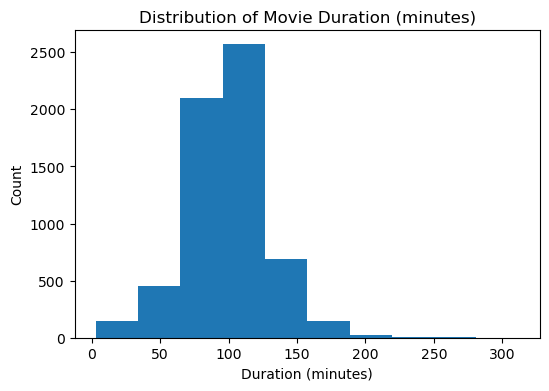

In [374]:
plt.figure(figsize = (6,4))
plt.hist(movie_duration)
plt.title('Distribution of Movie Duration (minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()

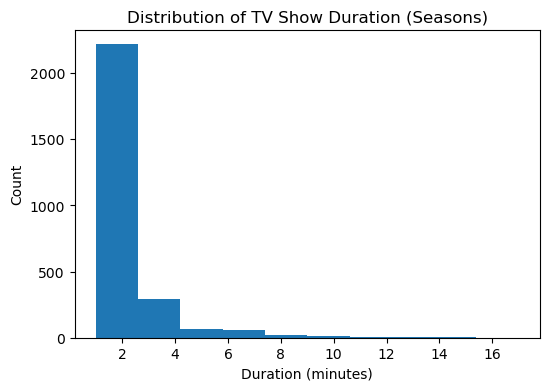

In [378]:
plt.figure(figsize = (6,4))
plt.hist(tv_duration)
plt.title('Distribution of TV Show Duration (Seasons)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()

In [380]:
Q1 = movie_duration.quantile(0.25)
Q3 = movie_duration.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("Lower bound:", lower_bound, "Upper bound:", upper_bound)

outliers = movie_duration[(movie_duration < lower_bound) | (movie_duration > upper_bound)]
print("Number of outliers:", outliers.count())

Q1: 87.0 Q3: 114.0 IQR: 27.0
Lower bound: 46.5 Upper bound: 154.5
Number of outliers: 450


In [384]:
movie_duration.sort_values().head(5)

3777     3
2713     5
1484     8
1557     9
3535    10
Name: duration_num, dtype: int64

In [386]:
data.loc[[3777, 2713, 1484, 1557, 3535], ['title', 'type', 'duration', 'listed_in']]

,title,type,duration,listed_in
3777,Silent,Movie,3 min,"Children & Family Movies, Sci-Fi & Fantasy"
2713,Sol Levante,Movie,5 min,"Action & Adventure, Anime Features, Internatio..."
1484,Cops and Robbers,Movie,8 min,Dramas
1557,Canvas,Movie,9 min,"Children & Family Movies, Dramas"
3535,American Factory: A Conversation with the Obamas,Movie,10 min,Documentaries


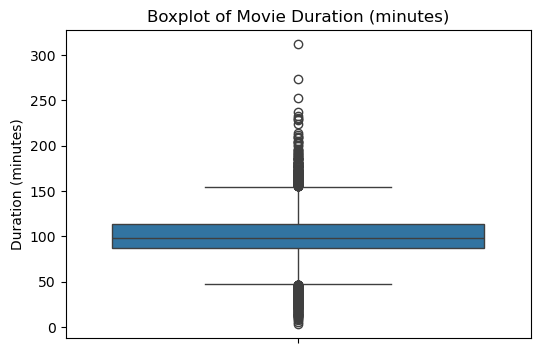

In [388]:
plt.figure(figsize=(6,4))
sns.boxplot(y=movie_duration)
plt.title('Boxplot of Movie Duration (minutes)')
plt.ylabel('Duration (minutes)')
plt.show()

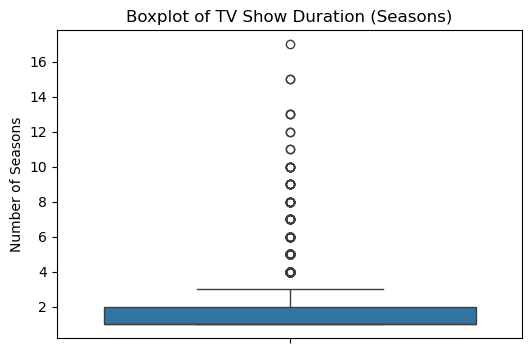

In [390]:
plt.figure(figsize=(6,4))
sns.boxplot(y=tv_duration)
plt.title('Boxplot of TV Show Duration (Seasons)')
plt.ylabel('Number of Seasons')
plt.show()